In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [9]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos


{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [12]:
block_size = 3 # context length, how many chars we take to predict next
X, Y = [], [] # input and labels
for w in words[:5]:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # rolling window, crop and append new
X = torch.tensor(X)
Y = torch.tensor(Y)

In [13]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [14]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [16]:
C = torch.randn((27, 2)) # embedding matrix, initialized randomly

In [ ]:
F.one_hot(torch.tensor(5), num_classes=27).float() # vector of size 27, 5th entry is 1 and all other are 0


torch.Size([27])

In [ ]:
# embed all of X into weight matrix X 
emb = C[X]
emb.shape # 32 training examples from X, context length of 3, embedded dim of 2

torch.Size([32, 3, 2])

In [23]:
emb

tensor([[[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301]],

        [[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [-0.8939, -1.6757]],

        [[ 1.1642, -0.9301],
         [-0.8939, -1.6757],
         [-0.9678,  0.9566]],

        [[-0.8939, -1.6757],
         [-0.9678,  0.9566],
         [-0.9678,  0.9566]],

        [[-0.9678,  0.9566],
         [-0.9678,  0.9566],
         [ 0.4330, -1.3514]],

        [[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301]],

        [[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 0.9675, -0.1997]],

        [[ 1.1642, -0.9301],
         [ 0.9675, -0.1997],
         [ 0.2715, -1.1721]],

        [[ 0.9675, -0.1997],
         [ 0.2715, -1.1721],
         [-0.8586,  0.0916]],

        [[ 0.2715, -1.1721],
         [-0.8586,  0.0916],
         [-0.3207, -1.7247]],

        [[-0.8586,  0.0916],
         [-0.3207, -1.7247],
         [-0.8586,  0.0916]],

        [[-0.3207, -1

In [21]:
W1 = torch.randn((6, 100)) # 6 = 3 x 2 from above, 100 neurons
b1 = torch.randn(100)

Want emb @ W1 + b1, but dimension mismatch. Thus concatinate emb into 32 by 6

In [25]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
# squashes 32x3x2 by dimension 1 into 32x6, turns each 3x2 matrix into 1x6 row vector

tensor([[ 1.1642, -0.9301,  1.1642, -0.9301,  1.1642, -0.9301],
        [ 1.1642, -0.9301,  1.1642, -0.9301, -0.8939, -1.6757],
        [ 1.1642, -0.9301, -0.8939, -1.6757, -0.9678,  0.9566],
        [-0.8939, -1.6757, -0.9678,  0.9566, -0.9678,  0.9566],
        [-0.9678,  0.9566, -0.9678,  0.9566,  0.4330, -1.3514],
        [ 1.1642, -0.9301,  1.1642, -0.9301,  1.1642, -0.9301],
        [ 1.1642, -0.9301,  1.1642, -0.9301,  0.9675, -0.1997],
        [ 1.1642, -0.9301,  0.9675, -0.1997,  0.2715, -1.1721],
        [ 0.9675, -0.1997,  0.2715, -1.1721, -0.8586,  0.0916],
        [ 0.2715, -1.1721, -0.8586,  0.0916, -0.3207, -1.7247],
        [-0.8586,  0.0916, -0.3207, -1.7247, -0.8586,  0.0916],
        [-0.3207, -1.7247, -0.8586,  0.0916,  0.4330, -1.3514],
        [ 1.1642, -0.9301,  1.1642, -0.9301,  1.1642, -0.9301],
        [ 1.1642, -0.9301,  1.1642, -0.9301,  0.4330, -1.3514],
        [ 1.1642, -0.9301,  0.4330, -1.3514, -0.3207, -1.7247],
        [ 0.4330, -1.3514, -0.3207, -1.7

In [ ]:
# code above doesnt generalize
torch.unbind(emb, 1) # deletes a dimension (default 0) to change shape of tensor

(tensor([[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [-0.8939, -1.6757],
         [-0.9678,  0.9566],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 0.9675, -0.1997],
         [ 0.2715, -1.1721],
         [-0.8586,  0.0916],
         [-0.3207, -1.7247],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 0.4330, -1.3514],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [-0.8586,  0.0916],
         [-1.5852, -0.4050],
         [ 0.4330, -1.3514],
         [-0.6581,  1.2341],
         [-0.8939, -1.6757],
         [ 0.2715, -1.1721],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [-1.5852, -0.4050],
         [ 0.9675, -0.1997],
         [ 1.1054,  0.0961],
         [-0.2502, -0.8632]]),
 tensor([[ 1.1642, -0.9301],
         [ 1.1642, -0.9301],
         [-0

In [28]:
# Finally
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

## Another approach
torch has .view(x, y, ...) function such that we can change a tensor into any shape as long as xy... have the same total dimension. 

In [30]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [ ]:
# so we can do
h = emb.view(emb.shape[0], # 32
            6) @ W1 + b1
h
# this is more efficient than cat bc it creates new tensors

tensor([[-0.1518, -0.2327, -1.5983,  ..., -0.9120,  3.6210,  1.3663],
        [-2.4027,  0.5577, -2.6977,  ...,  3.3363,  1.9656,  1.1825],
        [-3.8342,  1.3149, -2.4865,  ...,  4.4368,  2.0165,  4.4232],
        ...,
        [-0.3865,  0.2246, -0.9327,  ...,  1.2743,  0.2630, -1.7625],
        [-3.0006,  2.3799, -2.0049,  ...,  4.4557, -0.4777,  0.0840],
        [-1.6450, -0.0386,  1.0853,  ...,  0.4392,  3.8400, -2.5205]])

In [ ]:
h = torch.tanh(h)

torch.Size([32, 100])

In [ ]:
# broadcasting, add bi to all rows of emb @ W1
# 32 x 100 ---> 32 x 100
# 100 --------> 1  x 100

In [38]:
W2 = torch.rand((100, 27)) # input 100 neurons, 27 output neurons bc 27 possible letters
b2 = torch.rand(27)
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [39]:
counts = logits.exp()

In [41]:
probs = counts / counts.sum(1, keepdims=True)
probs.shape

torch.Size([32, 27])

In [ ]:
# probability of predicting correct output Y for each column
probs[torch.arange(32), Y]

tensor([0.0282, 0.0164, 0.1076, 0.0074, 0.0430, 0.0011, 0.0061, 0.0265, 0.0043,
        0.0248, 0.0088, 0.0775, 0.0004, 0.0155, 0.0004, 0.0060, 0.0161, 0.0232,
        0.0012, 0.1593, 0.3395, 0.0015, 0.0579, 0.0010, 0.0052, 0.0044, 0.0010,
        0.0557, 0.0259, 0.0397, 0.0020, 0.1122])

In [46]:
loss = -probs[torch.arange(32), Y].log().mean()

## Summary up to now

In [47]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # total num parameters

3481

NN setup

In [59]:
for p in parameters:
    p.requires_grad = True

In [63]:
for _ in range(100):
    # forward pass
    emb = C[X] # 32x3x2
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss= -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y) # same function as 3 lines above
    # more efficient in forward pass storage and backward pass
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

3.262141704559326
2.961380958557129
2.6982972621917725
2.469712972640991
2.271660327911377
2.1012840270996094
1.9571772813796997
1.8374855518341064
1.7380963563919067
1.65351140499115
1.579089879989624
1.5117663145065308
1.4496047496795654
1.3913120031356812
1.3359925746917725
1.2830528020858765
1.2321910858154297
1.1833815574645996
1.1367989778518677
1.0926642417907715
1.0510923862457275
1.0120267868041992
0.9752704501152039
0.9405564665794373
0.9076123833656311
0.8761923909187317
0.8460890054702759
0.8171356320381165
0.7891988754272461
0.7621745467185974
0.7359813451766968
0.7105579972267151
0.6858608722686768
0.661865234375
0.6385657787322998
0.6159818768501282
0.5941658020019531
0.5732106566429138
0.5532562732696533
0.5344880819320679
0.5171169638633728
0.5013313889503479
0.4872426688671112
0.47484052181243896
0.4639976918697357
0.45451435446739197
0.4461709260940552
0.4387664496898651
0.4321332573890686
0.4261389374732971
0.4206799268722534
0.4156752824783325
0.41106149554252625
0

In above, we only have 32 examples (5 words) yet over 3000 parameters, therefore easy to overfit and reach very low loss

## Full Dataset

In [64]:
block_size = 3 # context length, how many chars we take to predict next
X, Y = [], [] # input and labels
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # rolling window, crop and append new
X = torch.tensor(X)
Y = torch.tensor(Y)

In [65]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [66]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [67]:
for p in parameters:
    p.requires_grad = True

In [ ]:
for _ in range(100):
    # forward pass
    emb = C[X] 
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss= -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y) # same function as 3 lines above
    # more efficient in forward pass storage and backward pass
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

19.505229949951172
17.084484100341797
15.776531219482422
14.833340644836426
14.002604484558105
13.253263473510742
12.57991886138916
11.983102798461914
11.47049331665039
11.05185604095459
10.709587097167969
10.407631874084473
10.127808570861816
9.864364624023438
9.614503860473633
9.376439094543457
9.148944854736328
8.931109428405762
8.722230911254883
8.521748542785645
8.32922649383545
8.144325256347656
7.966790676116943
7.796450138092041
7.633184909820557
7.476907730102539
7.327520847320557
7.184885501861572
7.04879093170166
6.918952465057373
6.795018196105957
6.6766037940979
6.563317775726318
6.454790115356445
6.350668907165527
6.250643253326416
6.15443229675293
6.06178617477417
5.972482681274414
5.886328220367432
5.803147315979004
5.722784519195557
5.645095348358154
5.5699462890625
5.497213840484619
5.426781177520752
5.358536243438721
5.2923760414123535
5.228204250335693
5.165928840637207
5.105469226837158
5.046748638153076
4.989699363708496
4.934262275695801
4.880381107330322
4.82800

Minibatching:

In [71]:
torch.randint(0, X.shape[0], (32, )) # 32 nums between 0 and X.shape[0]

tensor([ 70566, 204865, 171044, 132151, 127626, 145266,  11216,  95675, 186250,
        199692, 175580, 123869, 211064, 143732,  38440, 215780,  25487,  46658,
         15975, 199437,  29769, 201151, 224124, 221099,  32322,  44527, 106336,
        215637, 218946,   7119,  26378, 144074])

In [84]:
for _ in range(100):

    # minibatch
    ix = torch.randint(0, X.shape[0], (32, ))
    # forward pass
    emb = C[X[ix]] # 32x3x2
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss= -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix]) # same function as 3 lines above
    # more efficient in forward pass storage and backward pass

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())


2.834085702896118


In [85]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.6881, grad_fn=<NllLossBackward0>)

Determining learning rates: first find reasonable upper and lower bound, for example 0.001 and 1

In [86]:
lre = torch.linspace(-3, 0, 1000) # 1000 numbers between -3 and 0
lrs = 10 ** lre # this is our different learning rates

In [90]:
lri= []
lossi = []

for i in range(1000):

    ix = torch.randint(0, X.shape[0], (32, ))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6)  @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    lri.append(lre[i])
    lossi.append(loss.item())

7.899834156036377
8.762898445129395
8.7660493850708
6.510236740112305
6.570328712463379
6.486530780792236
7.278823375701904
7.733682155609131
9.152006149291992
5.934767723083496
8.670782089233398
8.159651756286621
7.143984317779541
7.979820251464844
6.050823211669922
5.838772773742676
7.110182762145996
6.613859176635742
7.2837605476379395
6.453775405883789
7.322559356689453
6.475796222686768
5.7412590980529785
6.906820774078369
8.110248565673828
5.648002624511719
7.006797790527344
8.203790664672852
5.427730083465576
6.621353626251221
6.841597557067871
7.573623180389404
6.68686056137085
6.894718170166016
7.9831624031066895
6.72505521774292
7.116275310516357
6.282676696777344
5.370901584625244
6.478703022003174
6.501379489898682
6.330993175506592
6.385241508483887
5.980395317077637
6.220468044281006
8.997293472290039
6.514713287353516
7.476531028747559
7.031624794006348
7.226027965545654
5.479105472564697
6.37876558303833
7.4500555992126465
6.443622589111328
6.315093994140625
6.783750057

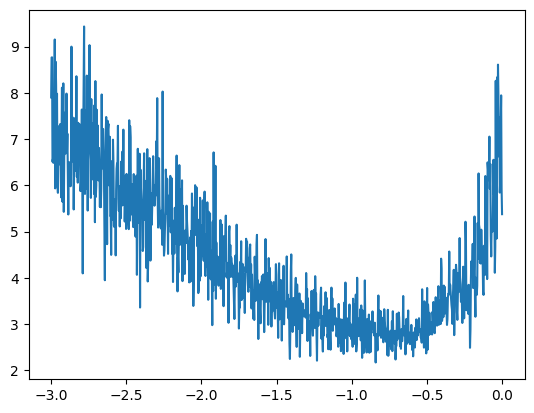

In [91]:
plt.plot(lri, lossi)

From this, we can see lr = 0.1 works well. After many iterations, we can decrease lr by factor of 10 (to 0.01) and run a bit more to decrease loss

To prevent overtraining, split data into
training(80%) to train parameters, dev/validation(10%) for hyperparameter tuning, test(10%) to evaluate model performance

In [94]:
block_size = 3 # context length, how many chars we take to predict next

def build_dataset(words):
    X, Y = [], [] # input and labels
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # rolling window, crop and append new
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words) # mix up words randomly
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [95]:
# new training data
Xtr.shape, Ytr.shape

(torch.Size([182437, 3]), torch.Size([182437]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [99]:
for p in parameters:
    p.requires_grad = True

In [97]:
lre = torch.linspace(-3, 0, 1000) # 1000 numbers between -3 and 0
lrs = 10 ** lre # this is our different learning rates

In [109]:
lri = []
lossi = []

for i in range(10000):

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]] # 32x3x2
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update 
    lr = 0.1 # found previously to be optimal
    for p in parameters:
        p.data += -lr * p.grad


In [110]:
print(loss.item())

2.628227710723877


In [111]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5044, grad_fn=<NllLossBackward0>)

Training and dev loss are about equal, so no overfitting. In fact, we are underfitting as NN is very small, so by scaling up we can improve performance

In [116]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g) # increase neurons 100 -> 300
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [120]:
stepi = []
lossi = []

for i in range(30000):

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]] # 32x3x2
    h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update 
    lr = 0.025 # found previously to be optimal
    for p in parameters:
        p.data += -lr * p.grad
    
    stepi.append(i)
    lossi.append(loss.item())


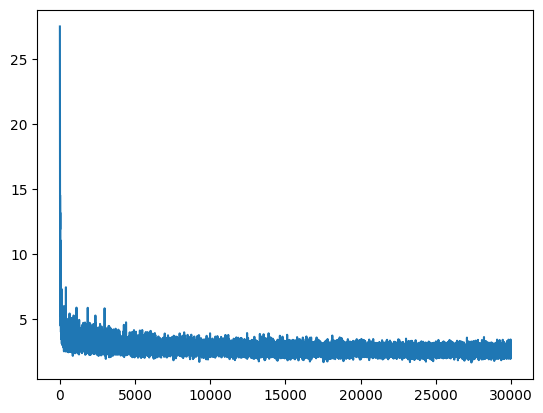

In [118]:
plt.plot(stepi, lossi)

Thickness at the end comes from minibatch noise

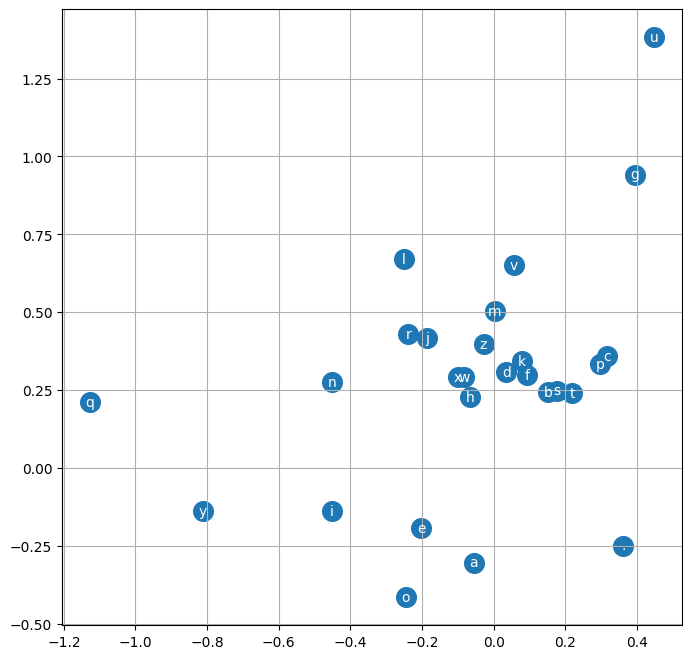

In [121]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Since we are underfitting and increasing layer neuron count didnt improve count, lets try to improve embedding cost

In [124]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g) # increase embeddings 2 -> 10
W1 = torch.randn((30, 200), generator=g) 
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [125]:
stepi = []
lossi = []


In [131]:
for i in range(50000):

    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update 
    lr = 0.1 # found previously to be optimal
    for p in parameters:
        p.data += -lr * p.grad
    
    stepi.append(i)
    lossi.append(loss.log10().item()) # log makes plot nicer


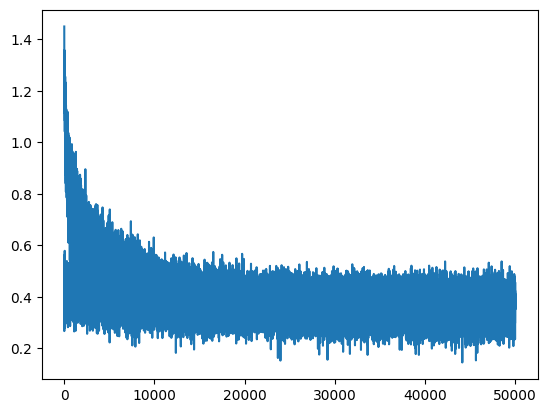

In [132]:
plt.plot(stepi, lossi)

In [133]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2665, grad_fn=<NllLossBackward0>)

In [134]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2988, grad_fn=<NllLossBackward0>)

Training and validation are now growing apart, showing less underfitting more overfitting

After we are done tuning hyperparameters, we run model on test set a single time, which gives us the final performance metrics

In [138]:
# sample from model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

chriah.
quilleri.
kemriy.
thiyah.
cassie.
mahnen.
delyah.
jareei.
nellarahciedhvie.
leigh.
ham.
elin.
quint.
shon.
emiriah.
hiraeloziearyni.
jaxee.
druan.
edde.
eia.
